In [7]:
"""
3-panel interaction figure (AUC) for fusion strategies with vs without washout.

- Panel A: Full dataset
- Panel B: Group 7
- Panel C: Group 5

Each panel: two lines (with washout = solid, without washout = dashed) + error bars (± SD).
Uses ONLY matplotlib (journal-friendly, grayscale safe).
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1) Enter your summary numbers
# -----------------------------
strategies = ["early", "late_avg", "late_stack", "mask_token"]
x = np.arange(len(strategies))




In [ ]:
from config import DATA_ROOT_DIR
import os 
data_root_dir = os.path.join(DATA_ROOT_DIR, "output/fusion_strategy_eval")
overall_results_df = pd.read_csv(f"{data_root_dir}/overall_comparison_results.csv")
overall_results_without_washout_df = pd.read_csv(f"{data_root_dir}/overall_comparison_results_no_washout.csv")

group5_results_df = pd.read_csv(f"{data_root_dir}/Group5_groupwise_comparison_results.csv")
group7_results_df = pd.read_csv(f"{data_root_dir}/Group7_groupwise_comparison_results.csv")

group5_results_without_washout_df = pd.read_csv(f"{data_root_dir}/Group5_groupwise_comparison_results_no_washout.csv")
group7_results_without_washout_df = pd.read_csv(f"{data_root_dir}/Group7_groupwise_comparison_results_no_washout.csv")

def parse_auc_table(df):
    """
    Convert a dataframe with columns:
    Strategy | AUC (mean±sd)
    into two lists: mean, sd
    """
    means = []
    sds = []

    for val in df["AUC"]:
        mean_str, sd_str = val.split("±")
        means.append(float(mean_str))
        sds.append(float(sd_str))

    return means, sds

mean_with, sd_with = parse_auc_table(overall_results_df)
mean_without, sd_without = parse_auc_table(overall_results_without_washout_df)

mean_group5_with, sd_group5_with = parse_auc_table(group5_results_df)
mean_group5_without, sd_group5_without = parse_auc_table(group5_results_without_washout_df)

mean_group7_with, sd_group7_with = parse_auc_table(group7_results_df)
mean_group7_without, sd_group7_without = parse_auc_table(group7_results_without_washout_df)

data = {
    "Full dataset": {
        "with": {
            "mean": mean_with,
            "sd": sd_with
        },
        "without": {
            "mean": mean_without,
            "sd": sd_without
        }
    },
    "Group 5": {
        "with": {
            "mean": mean_group5_with,
            "sd": sd_group5_with
        },
        "without": {
            "mean": mean_group5_without,
            "sd": sd_group5_without
        }
    },
    "Group 7": {
        "with": {
            "mean": mean_group7_with,
            "sd": sd_group7_with
        },
        "without": {
            "mean": mean_group7_without,
            "sd": sd_group7_without
        }
    }
}



In [9]:

# data = {
#     "Full dataset": {
#         "with":  {"mean": [0.8560, 0.8208, 0.7485, 0.8589], "sd": [0.0326, 0.0176, 0.0463, 0.0240]},
#         "without":{"mean": [0.8440, 0.5536, 0.6221, 0.8589], "sd": [0.0366, 0.0415, 0.0285, 0.0240]},
#     },
#     "Group 7": {
#         "with":  {"mean": [0.8502, 0.8463, 0.8144, 0.8614], "sd": [0.0632, 0.0747, 0.0577, 0.0462]},
#         "without":{"mean": [0.8058, 0.6552, 0.7823, 0.8614], "sd": [0.1040, 0.1390, 0.0626, 0.0462]},
#     },
#     "Group 5": {
#         "with":  {"mean": [0.7683, 0.7299, 0.7088, 0.7653], "sd": [0.0688, 0.0721, 0.1001, 0.0823]},
#         "without":{"mean": [0.7769, 0.5079, 0.4914, 0.7653], "sd": [0.0825, 0.0538, 0.0622, 0.0823]},
#     },
# }



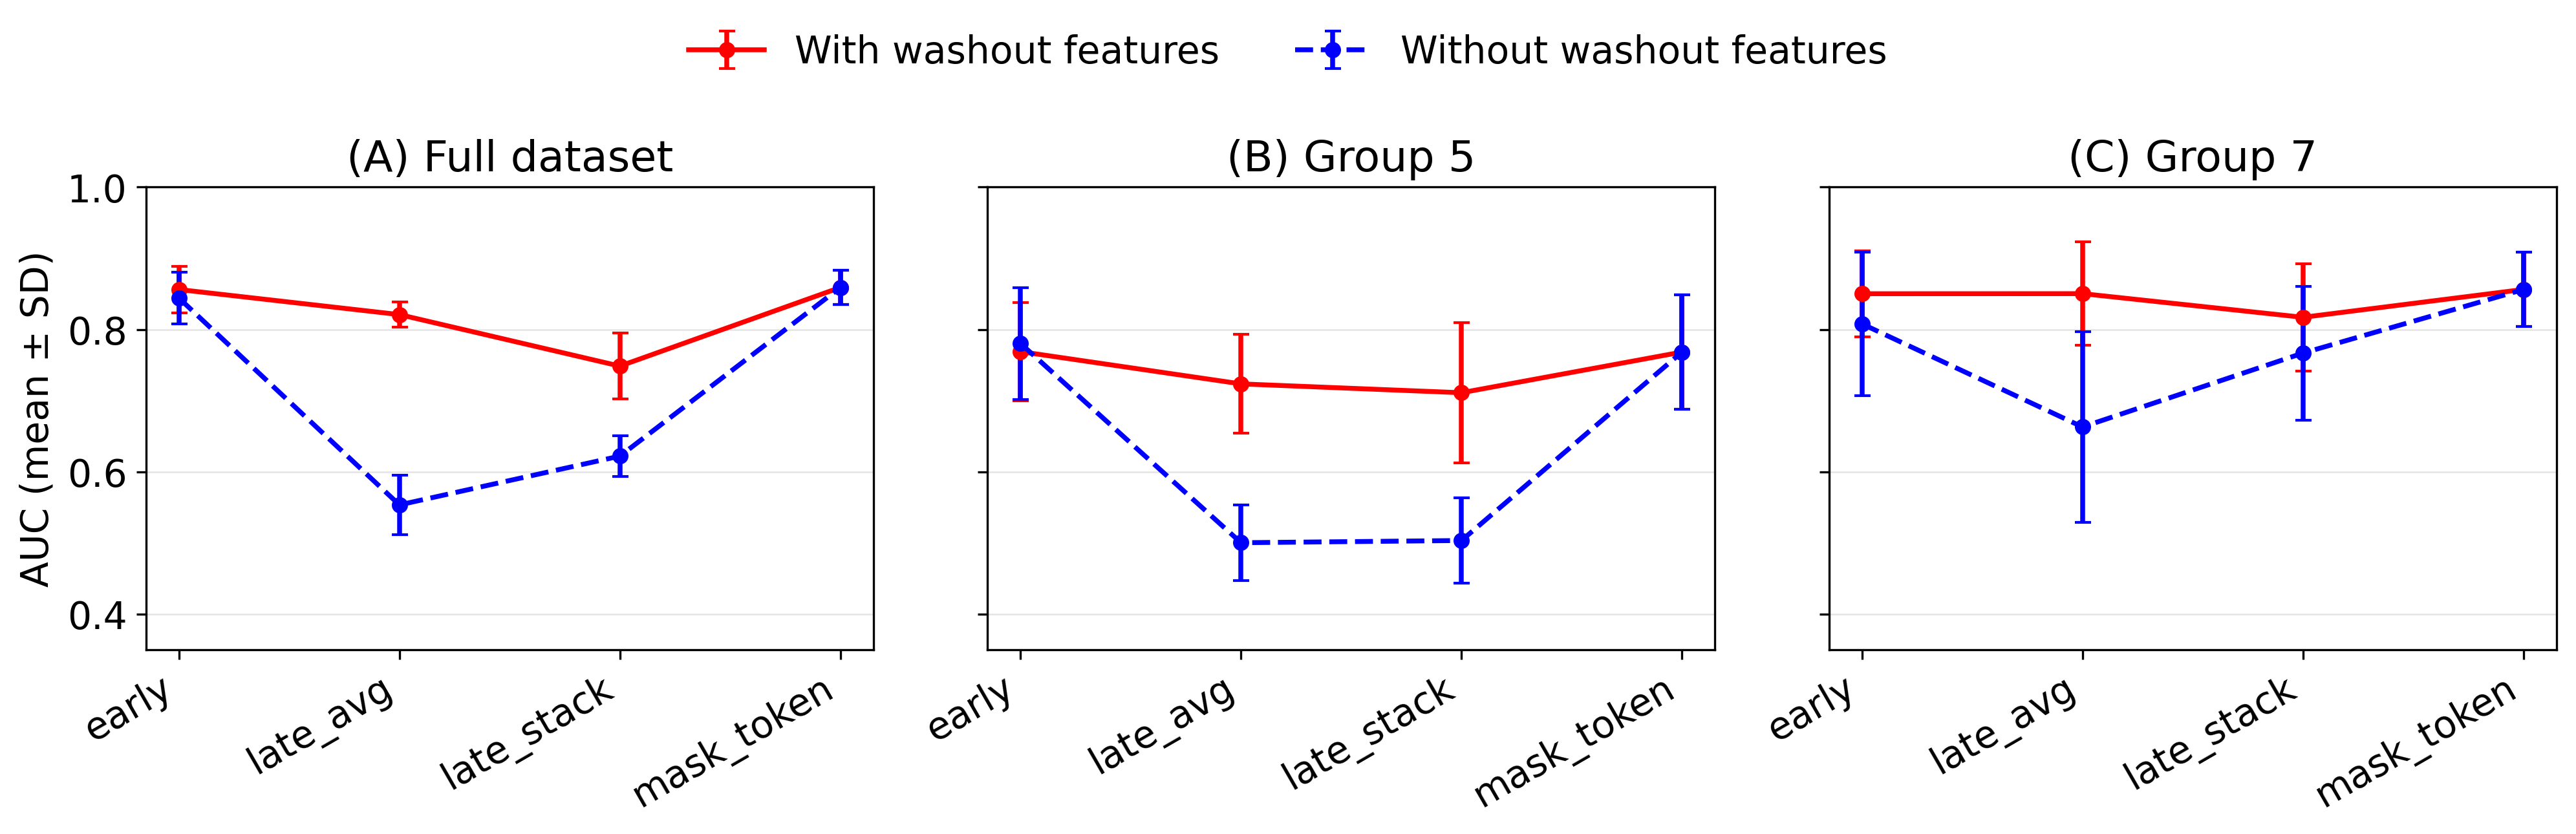

In [11]:

# -----------------------------
# 2) Plot
# -----------------------------
# Grayscale-friendly styling
WITH_STYLE = dict(linestyle="-", marker="o")
WITHOUT_STYLE = dict(linestyle="--", marker="o")

# Shared y-limits across panels for fair comparison
# (You can adjust these if your journal prefers tighter bounds.)
YMIN, YMAX = 0.35, 1.0

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13.5, 4.2), sharey=True, dpi=300)
plt.rcParams.update({'font.size': 14})  
panel_labels = ["(A)", "(B)", "(C)"]
panel_titles = list(data.keys())

for ax, label, title in zip(axes, panel_labels, panel_titles):
    with_mean = np.array(data[title]["with"]["mean"], dtype=float)
    with_sd   = np.array(data[title]["with"]["sd"], dtype=float)
    wo_mean   = np.array(data[title]["without"]["mean"], dtype=float)
    wo_sd     = np.array(data[title]["without"]["sd"], dtype=float)

    # "with washout": solid line + error bars
    ax.errorbar(
        x, with_mean, yerr=with_sd,
        capsize=3, linewidth=1.8, markersize=5,color="red",
        label="With washout features", **WITH_STYLE
    )

    # "without washout": dashed line + error bars
    ax.errorbar(
        x, wo_mean, yerr=wo_sd,
        capsize=3, linewidth=1.8, markersize=5,color="blue",
        label="Without washout features", **WITHOUT_STYLE
    )

    ax.set_title(f"{label} {title}", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=30, ha="right")
    ax.set_ylim(YMIN, YMAX)

    # Light, journal-like grid
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)

axes[0].set_ylabel("AUC (mean ± SD)", fontsize=14)

# One legend for the whole figure (top center)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.tight_layout(rect=[0, 0, 1, 0.93])

# Save high-resolution, publication-ready files
fig.savefig("fusion_washout_interaction_auc_3panel.png", dpi=300, bbox_inches="tight")

plt.show()